# EDA - Atividade extensionista

## 1. Bibliotecas e leitura do arquivo

In [1221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from itertools import combinations
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment

In [ ]:
df = pd.read_csv('eng_amb_ns_tab_unificada.csv')

In [ ]:
df.shape

## 2. Metadados

In [ ]:
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)

    return metadata

metadata_df = generate_metadata(df)
metadata_df

### Tratamento de dados

### 3.1 Tipo dos dados

#### matricula

In [ ]:
# Converter matricula de float64 para object (string)
# É um identificador de período, não um valor numérico
df['matricula'] = df['matricula'].astype(str)

# Verificar resultado
print(df['matricula'].dtype)
print(df['matricula'].head(3))

#### prazo_conclusao

In [ ]:
# Converter prazo_conclusao de float64 (ex: 2028.1) para string formatada 'AAAA.S'
df['prazo_conclusao'] = df['prazo_conclusao'].apply(
    lambda x: f"{int(x)}.{int(round((x % 1) * 10))}" if pd.notna(x) else np.nan
    # int(x)            → extrai o ano (parte inteira)
    # (x % 1) * 10      → isola o decimal e converte para semestre (0.1 → 1, 0.2 → 2)
    # round()           → evita imprecisão de ponto flutuante (ex: 0.09999... → 0.1)
    # pd.notna(x)       → preserva nulos como np.nan em vez de converter para 'nan'
)

# Verificar resultado
print(df['prazo_conclusao'].dtype)
print(df['prazo_conclusao'].head(3))

In [ ]:
# Extrair componentes numéricos de prazo_conclusao para uso em cálculos futuros
# Exemplo de uso: quantos semestres faltavam quando o aluno cancelou a matrícula

# Ano previsto de conclusão (ex: '2028.1' → 2028)
df['prazo_conclusao_ano'] = (
    df['prazo_conclusao']
    .str.split('.')           # separa '2028.1' em ['2028', '1']
    .str[0]                   # pega o primeiro elemento → '2028'
    .astype('Int64')          # converte para inteiro nullable (suporta nulos)
)

# Semestre previsto de conclusão (ex: '2028.1' → 1)
df['prazo_conclusao_semestre'] = (
    df['prazo_conclusao']
    .str.split('.')           # separa '2028.1' em ['2028', '1']
    .str[1]                   # pega o segundo elemento → '1'
    .astype('Int64')          # converte para inteiro nullable (suporta nulos)
)

# Verificar resultado
print(df[['prazo_conclusao', 'prazo_conclusao_ano', 'prazo_conclusao_semestre']].head(3))
print(f"\nTipo prazo_conclusao_ano      : {df['prazo_conclusao_ano'].dtype}")
print(f"Tipo prazo_conclusao_semestre : {df['prazo_conclusao_semestre'].dtype}")

#### ensino_medio_conclusao

In [ ]:
# Converter ensino_medio_ano_concl de float64 para inteiro nullable
# Int64 (nullable) pois a coluna pode conter nulos
df['ensino_medio_ano_concl'] = df['ensino_medio_ano_concl'].astype('Int64')

# Verificar resultado
print(df['ensino_medio_ano_concl'].dtype)
print(df['ensino_medio_ano_concl'].head(3))

### Criar colunas

#### Target

In [ ]:
# Criar coluna target binária a partir de situacao_matricula
# 1 = evadiu (CANCELADO), 0 = não evadiu (todos os demais)
# Usa Int64 nullable para manter consistência com as demais colunas inteiras do df
df['target'] = (df['situacao_matricula'] == 'CANCELADO').astype('Int64')

# Verificar resultado
print(df['target'].value_counts(dropna=False))
print(f"\nTipo: {df['target'].dtype}")

#### idade_ingresso

In [ ]:
# Dicionário para converter mês em português
meses_pt = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8,
    'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

def parse_data_nascimento(data_str):
    try:
        partes = data_str.split(', ')
        mes_dia = partes[1].split(' ')
        mes = meses_pt[mes_dia[0].lower()]
        dia = int(mes_dia[1])
        ano = int(partes[2])
        return pd.Timestamp(year=ano, month=mes, day=dia)
    except:
        return pd.NaT

def parse_safra(safra_val):
    try:
        safra_str = str(safra_val)
        ano, sem = safra_str.split('.')
        mes = 1 if sem == '1' else 7
        return pd.Timestamp(year=int(ano), month=mes, day=1)
    except:
        return pd.NaT

# Criar as duas colunas auxiliares
df['data_nascimento_dt'] = df['data_nascimento'].apply(parse_data_nascimento)
df['safra_dt'] = df['safra'].apply(parse_safra)

# Calcular idade no ingresso
df['idade_ingresso'] = (
    (df['safra_dt'] - df['data_nascimento_dt']).dt.days // 365
)

df[['data_nascimento', 'safra', 'idade_ingresso']].sample(10)

#### Anos após a  conclusão do ensino médio

In [1281]:
# Calcula quantos anos se passaram entre a conclusão do ensino médio e o ingresso
df['anos_apos_em'] = (df['safra_ano'] - df['ensino_medio_ano_concl']).astype('Int64')

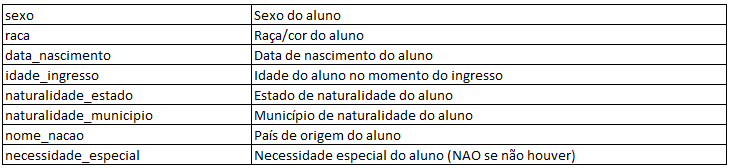

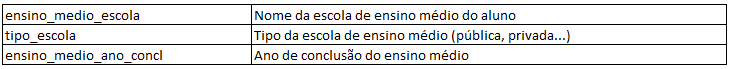

## 3. Análise exploratória de dados

In [ ]:
df.describe()

In [ ]:
df.info()

### Rendimento global

In [ ]:
plt.close('all')

# --- DataFrame: rendimento_global por aluno único ---
df_rend = (
    df
    .drop_duplicates('matricula')
    [['matricula', 'target', 'rendimento_global']]
    .dropna(subset=['rendimento_global'])
    .reset_index(drop=True)
)

# Separa os grupos por situação da matrícula
rend_cancelados     = df_rend[df_rend['target'] == 1]['rendimento_global']
rend_nao_cancelados = df_rend[df_rend['target'] == 0]['rendimento_global']

# Paleta de cores padrão do projeto
cores = {'Evadiram': '#d85a30', 'Permaneceram': '#3266ad'}

# --- Layout: boxplot em cima, histograma embaixo, eixo x compartilhado ---
fig = plt.figure(figsize=(10, 4))  # altura aumentada para acomodar a legenda
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)

ax_box  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharex=ax_box)  # compartilha o eixo x com o boxplot

# ==============================
# PAINEL SUPERIOR — Boxplot
# ==============================
ax_box.grid(False)

bp = ax_box.boxplot(
    [rend_nao_cancelados, rend_cancelados],
    vert=False,
    patch_artist=True,       # necessário para colorir as caixas
    widths=0.7,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

# Aplica cores às caixas (ordem: Permaneceram=1, Evadiram=2)
bp['boxes'][0].set_facecolor(cores['Permaneceram'])
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(cores['Evadiram'])
bp['boxes'][1].set_alpha(0.7)

# Rótulos do eixo y do boxplot
ax_box.set_yticks([1, 2])
ax_box.set_yticklabels(['Permaneceram', 'Evadiram'], fontsize=11)

# Remove bordas desnecessárias e oculta o eixo x (compartilhado com o histograma)
ax_box.spines[['top', 'right', 'bottom']].set_visible(False)
ax_box.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

ax_box.set_title(
    'Rendimento global dos estudantes que evadiram e que permaneceram',
    fontsize=15, fontweight='bold', pad=12
)

# ==============================
# PAINEL INFERIOR — Histograma
# ==============================
ax_hist.grid(False)

# Histogramas sobrepostos por grupo
ax_hist.hist(rend_nao_cancelados, bins=30, color=cores['Permaneceram'],
             alpha=0.6, label=f"Permaneceram (n={len(rend_nao_cancelados)})")
ax_hist.hist(rend_cancelados, bins=30, color=cores['Evadiram'],
             alpha=0.6, label=f"Evadiram (n={len(rend_cancelados)})")

# Linhas verticais de média com desvio padrão na legenda
ax_hist.axvline(rend_nao_cancelados.mean(), color=cores['Permaneceram'],
                linestyle='--', linewidth=1.5,
                label=f"Média permaneceram: {rend_nao_cancelados.mean():.1f} (DP={rend_nao_cancelados.std():.1f})")
ax_hist.axvline(rend_cancelados.mean(), color=cores['Evadiram'],
                linestyle='--', linewidth=1.5,
                label=f"Média evadiram: {rend_cancelados.mean():.1f} (DP={rend_cancelados.std():.1f})")

ax_hist.set_xlabel('Rendimento global', fontsize=14)
ax_hist.set_ylabel('Nº estudantes', fontsize=14)
ax_hist.spines[['top', 'right']].set_visible(False)

# Legenda posicionada abaixo do histograma
# bbox_to_anchor=(0.5, -0.25): centraliza horizontalmente e desloca para baixo do eixo
# ncol=2: distribui os itens em 2 colunas para ficar compacto
ax_hist.legend(
    fontsize=13,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)

# Reserva espaço na margem inferior para a legenda não ser cortada
plt.subplots_adjust(bottom=0.22)

plt.show()

### Forma de ingresso

In [ ]:
# Garante um registro por aluno
df_alunos = df.drop_duplicates('matricula')

# Cria o dataframe com as métricas por forma de ingresso
forma_ingresso = (
    df_alunos
    .dropna(subset=['forma_ingresso_categoria'])
    .groupby('forma_ingresso_categoria', as_index=False)
    .agg(
        total=('matricula', 'count'),       # total de alunos únicos
        evadidos=('target', 'sum')          # total de evadidos
    )
    .assign(
        perc_forma_ing=lambda x: (x['total'] / x['total'].sum() * 100).round(1),         # percentual do total
        taxa_evasao=lambda x: (x['evadidos'] / x['total'] * 100).round(1),           # percentual de evasão
        nao_evadidos=lambda x: x['total'] - x['evadidos'],                            # quantidade de não evadidos
        taxa_nao_evasao=lambda x: (100 - (x['evadidos'] / x['total'] * 100)).round(1) # percentual de não evasão
    )
    .sort_values('total', ascending=False)
    .reset_index(drop=True)
)

print(forma_ingresso.to_string(index=False))

In [ ]:
plt.close('all')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ==============================
# GRÁFICO 1 — Percentual por forma de ingresso
# ==============================

df_plot1 = forma_ingresso.sort_values('perc_forma_ing', ascending=True)

bars1 = ax1.barh(
    df_plot1['forma_ingresso_categoria'],
    df_plot1['perc_forma_ing'],
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

# Exibe o valor percentual ao lado de cada barra
for bar, val in zip(bars1, df_plot1['perc_forma_ing']):
    ax1.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=20, color='#444444'
    )

ax1.set_title('Percentual de estudantes por forma de ingresso',
              fontsize=24, fontweight='bold', pad=30)
ax1.set_xlabel('Percentual de estudantes (%)', fontsize=24, labelpad=10)
ax1.set_xlim(0, df_plot1['perc_forma_ing'].max() * 1.2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=20)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(False)

# ==============================
# GRÁFICO 2 — Taxa de evasão por forma de ingresso
# ==============================

df_plot2 = forma_ingresso.sort_values('taxa_evasao', ascending=True)

bars2 = ax2.barh(
    df_plot2['forma_ingresso_categoria'],
    df_plot2['taxa_evasao'],
    color='#d85a30',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

# Exibe o valor percentual e o n ao lado de cada barra
for bar, val, total in zip(bars2, df_plot2['taxa_evasao'], df_plot2['total']):
    ax2.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={total:,})',
        va='center', fontsize=20, color='#444444'
    )

# Linha de referência: média geral de evasão
media_geral = forma_ingresso['evadidos'].sum() / forma_ingresso['total'].sum() * 100
ax2.axvline(x=media_geral, color='#2E7D32', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(
    media_geral + 0.3,
    len(df_plot2) - 0.3,
    f'Média: {media_geral:.1f}%',
    color='#000000', fontsize=18, va='bottom'
)

ax2.set_title('Taxa de evasão por forma de ingresso',
              fontsize=24, fontweight='bold', pad=30)
ax2.set_xlabel('Taxa de evasão (%)', fontsize=24, labelpad=10)
ax2.set_xlim(0, df_plot2['taxa_evasao'].max() * 1.25)
ax2.tick_params(axis='x', labelsize=24)
ax2.tick_params(axis='y', labelsize=20)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

### Tempo entre o ano de conclusão do ensino médio e o ano de ingresso

In [ ]:
anos_apos_em = (
    df
    .drop_duplicates('matricula')          # garante um registro por aluno
    ['anos_apos_em']                       # seleciona apenas a coluna de interesse
    .value_counts()                        # conta alunos por valor
    .sort_index()                          # ordena pelo valor (crescente)
    .reset_index()                         # transforma o índice em coluna
    .rename(columns={
        'anos_apos_em': 'anos_apos_em',
        'count': 'total_alunos'
    })
)

# Adiciona coluna de percentual
anos_apos_em['percentual'] = (
    anos_apos_em['total_alunos'] / anos_apos_em['total_alunos'].sum() * 100
).round(1)

print(anos_apos_em)

In [ ]:
plt.close('all')

dados = df.drop_duplicates('matricula')['anos_apos_em'].dropna()

fig = plt.figure(figsize=(12, 4))
fig.suptitle('Número de estudantes por anos após conclusão do ensino médio',
             fontsize=18, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(2, 1, height_ratios=[0.5, 3], hspace=0.05)

ax_box  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharex=ax_box)

# ==============================
# PAINEL SUPERIOR — Boxplot
# ==============================
bp = ax_box.boxplot(
    dados,
    vert=False,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.2),
    capprops=dict(color='#555555', linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#555555')
)

bp['boxes'][0].set_facecolor('#b7bec8')
bp['boxes'][0].set_alpha(0.8)

ax_box.set_yticks([])
ax_box.grid(False)
ax_box.spines[['top', 'right', 'bottom']].set_visible(False)
ax_box.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# ==============================
# PAINEL INFERIOR — Histograma
# ==============================
n, bins, patches = ax_hist.hist(
    dados,
    bins=range(int(dados.min()), int(dados.max()) + 2),
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

ax_hist.set_xlabel('Anos', fontsize=18, labelpad=10)
ax_hist.set_ylabel('Nº estudantes', fontsize=18)
ax_hist.tick_params(axis='both', labelsize=16)
ax_hist.set_ylim(0, n.max() * 1.15)
ax_hist.grid(False)
ax_hist.spines[['top', 'right']].set_visible(False)

plt.show()

In [ ]:
# --- Calcula o limiar de outlier pelo critério do boxplot ---
df_alunos = df.drop_duplicates('matricula').copy()

q1  = df_alunos['anos_apos_em'].quantile(0.25)
q2  = df_alunos['anos_apos_em'].quantile(0.50)  # mediana
q3  = df_alunos['anos_apos_em'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

minimo = df_alunos['anos_apos_em'].min()
maximo = df_alunos['anos_apos_em'].max()

outliers = df_alunos[
    (df_alunos['anos_apos_em'] < limite_inferior) |
    (df_alunos['anos_apos_em'] > limite_superior)
]

print("=== Critério de outlier — Método de Tukey (IQR) ===")
print(f"Mínimo:            {minimo:.2f} anos")
print(f"Q1 (25%):          {q1:.2f} anos")
print(f"Q2 (50% mediana):  {q2:.2f} anos")
print(f"Q3 (75%):          {q3:.2f} anos")
print(f"Máximo:            {maximo:.2f} anos")
print(f"IQR (Q3 - Q1):     {iqr:.2f} anos")
print(f"\nLimite inferior:   {limite_inferior:.2f} anos  (Q1 - 1,5 × IQR)")
print(f"Limite superior:   {limite_superior:.2f} anos  (Q3 + 1,5 × IQR)")
print(f"\nTotal de outliers: {len(outliers)}")
print(f"  - Abaixo do limite inferior: {(df_alunos['anos_apos_em'] < limite_inferior).sum()}")
print(f"  - Acima do limite superior:  {(df_alunos['anos_apos_em'] > limite_superior).sum()}")
print(f"\nAlunos dentro dos limites: {(len(df_alunos) - len(outliers))}")

In [ ]:
# Ver a distribuição dos outliers
print(df_alunos[df_alunos['anos_apos_em'] > limite_superior]['anos_apos_em'].value_counts().sort_index())

# Se tiver a idade de ingresso, cruzar com ela
# print(df_alunos[df_alunos['anos_apos_em'] > limite_superior][['anos_apos_em', 'idade_ingresso']])

In [ ]:
# --- Calcula o limiar de outlier pelo critério do boxplot ---
df_alunos = df.drop_duplicates('matricula').copy()

q1  = df_alunos['anos_apos_em'].quantile(0.25)
q3  = df_alunos['anos_apos_em'].quantile(0.75)
iqr = q3 - q1
limiar_outlier = q3 + 1.5 * iqr

print("=== Critério de outlier — Q3 + 1,5 × IQR ===")
print(f"Q1:              {q1}")
print(f"Q3:              {q3}")
print(f"IQR (Q3 - Q1):   {iqr}")
print(f"Limiar outlier:  {limiar_outlier} anos")
print(f"\nAlunos acima do limiar: {(df_alunos['anos_apos_em'] > limiar_outlier).sum()}")
print(f"Alunos abaixo do limiar: {(df_alunos['anos_apos_em'] <= limiar_outlier).sum()}")

In [ ]:
qualidade = df[['matricula', 'safra', 'forma_ingresso' , 'anos_apos_em', 'rendimento_global', 'target']]
qualidade.head()

In [ ]:
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.
    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """
    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes.astype(str),   # <- conversão para string resolve o erro de comparação
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe)) * 100, 2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata = metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)
    return metadata

metadata_qualidade = generate_metadata(qualidade)
metadata_qualidade

In [ ]:
nulos = df[df['rendimento_global'].isnull()]
print(f"Registros nulos: {len(nulos)}")
print(f"Alunos únicos com nulos: {nulos['matricula'].nunique()}")

In [ ]:
# --- Verifica se há nulos de rendimento_semestral no 1º semestre ---
df_alunos_1sem = df.drop_duplicates('matricula').copy()

# Filtra registros do 1º semestre na instituição
df_1sem = df[df['safra'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre: {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:     {df_1sem['rendimento_global'].isna().sum()}")
print(f"Percentual de nulos:               {df_1sem['rendimento_global'].isna().mean()*100:.1f}%")

In [ ]:
# --- Calcula semestre_na_instituicao no df principal ---
df['semestre_na_instituicao'] = df.apply(
    lambda row: diferenca_semestres(row['safra'], row['ano_semestre_letivo']),
    axis=1
).astype('Int64')

# --- Verifica nulos de rendimento_semestral no 1º semestre ---
df_1sem = df[df['semestre_na_instituicao'] == 1].copy()

print("=== Nulos de rendimento_global no 1º semestre ===")
print(f"Total de registros no 1º semestre:   {len(df_1sem)}")
print(f"Nulos em rendimento_global:        {df_1sem['rendimento_global'].isna().sum()}")
print(f"Percentual de nulos:                  {df_1sem['rendimento_global'].isna().mean()*100:.1f}%")

# --- Distribuição dos nulos por semestre na instituição ---
print("\n=== Nulos de rendimento_global por semestre na instituição ===")
nulos_por_sem = (
    df[df['semestre_na_instituicao'] >= 1]
    .groupby('semestre_na_instituicao')
    .agg(
        Total=('rendimento_global', 'count'),
        Nulos=('rendimento_global', lambda x: x.isna().sum())
    )
    .reset_index()
)
nulos_por_sem['Pct_Nulos_%'] = (nulos_por_sem['Nulos'] / (nulos_por_sem['Total'] + nulos_por_sem['Nulos']) * 100).round(1)
print(nulos_por_sem.to_string(index=False))

In [ ]:
# --- Verifica se há nulos de rendimento_semestral no 1º semestre ---
df_alunos_1sem = df.drop_duplicates('matricula').copy()

# Filtra registros do 1º semestre na instituição
df_1sem = df[df['safra'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre: {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:     {df_1sem['rendimento_semestral'].isna().sum()}")
print(f"Percentual de nulos:               {df_1sem['rendimento_semestral'].isna().mean()*100:.1f}%")

In [ ]:
# --- Calcula semestre_na_instituicao no df principal ---
df['semestre_na_instituicao'] = df.apply(
    lambda row: diferenca_semestres(row['safra'], row['ano_semestre_letivo']),
    axis=1
).astype('Int64')

# --- Verifica nulos de rendimento_semestral no 1º semestre ---
df_1sem = df[df['semestre_na_instituicao'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre:   {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:        {df_1sem['rendimento_semestral'].isna().sum()}")
print(f"Percentual de nulos:                  {df_1sem['rendimento_semestral'].isna().mean()*100:.1f}%")

# --- Distribuição dos nulos por semestre na instituição ---
print("\n=== Nulos de rendimento_semestral por semestre na instituição ===")
nulos_por_sem = (
    df[df['semestre_na_instituicao'] >= 1]
    .groupby('semestre_na_instituicao')
    .agg(
        Total=('rendimento_semestral', 'count'),
        Nulos=('rendimento_semestral', lambda x: x.isna().sum())
    )
    .reset_index()
)
nulos_por_sem['Pct_Nulos_%'] = (nulos_por_sem['Nulos'] / (nulos_por_sem['Total'] + nulos_por_sem['Nulos']) * 100).round(1)
print(nulos_por_sem.to_string(index=False))

In [ ]:
# --- Investiga os alunos com nulo no rendimento_semestral no 1º semestre ---
df_alunos = df.drop_duplicates('matricula').copy()

# Identifica matrículas com nulo no 1º semestre
matriculas_nulo_1sem = (
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['matricula']
    .unique()
)

print(f"Alunos com nulo no rendimento_semestral no 1º semestre: {len(matriculas_nulo_1sem)}")

# Verifica o target desses alunos
df_nulo_1sem = df_alunos[df_alunos['matricula'].isin(matriculas_nulo_1sem)]

print("\n=== Target dos alunos com nulo no 1º semestre ===")
contagem = df_nulo_1sem['target'].value_counts().sort_index()
total    = contagem.sum()
for idx, val in contagem.items():
    label = 'Permaneceram/Concluíram' if idx == 0 else 'Evadiram'
    print(f"  {label}: {val} ({val/total*100:.1f}%)")

# Verifica forma de ingresso desses alunos
print("\n=== Forma de ingresso dos alunos com nulo no 1º semestre ===")
print(df_nulo_1sem['forma_ingresso_categoria'].value_counts())

# Verifica se há trancamento no 1º semestre
print("\n=== Situação de trancamento dos alunos com nulo no 1º semestre ===")
print(
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['tipo'].value_counts(dropna=False)
)

In [ ]:
# --- Verifica situação da matrícula dos alunos com nulo no 1º semestre ---
print("=== Situação da matrícula no 1º semestre (alunos com nulo) ===")
print(
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['situacao_matricula'].value_counts(dropna=False)
)

# Verifica todas as situações de matrícula desses alunos no df completo
print("\n=== Situação da matrícula (todos os semestres, alunos com nulo no 1º sem) ===")
print(
    df[df['matricula'].isin(matriculas_nulo_1sem)]['situacao_matricula']
    .value_counts(dropna=False)
)

# Verifica valores únicos da coluna para garantir que estamos usando os nomes certos
print("\n=== Valores únicos de situacao_matricula ===")
print(df['situacao_matricula'].value_counts(dropna=False))

In [ ]:
# --- Investiga os 34 EM_CURSO e 13 CONCLUIDO com nulo no 1º semestre ---
df_problema = df[
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO']))
].copy()

print("=== Alunos EM_CURSO ou CONCLUIDO com nulo no 1º semestre ===")
print(f"Total de registros: {len(df_problema)}")
print(f"Alunos únicos:      {df_problema['matricula'].nunique()}")

print("\n=== Situação da disciplina desses registros ===")
print(df_problema['situacao_disciplina_categoria'].value_counts(dropna=False))

print("\n=== Safra desses alunos ===")
print(df_problema['safra'].value_counts(dropna=False))

print("\n=== Target desses alunos ===")
df_prob_alunos = df.drop_duplicates('matricula')
df_prob_alunos = df_prob_alunos[df_prob_alunos['matricula'].isin(df_problema['matricula'].unique())]
print(df_prob_alunos['target'].value_counts())

In [ ]:
# --- Validação antes da imputação ---
print("=== Nulos em rendimento_semestral ANTES da imputação ===")
print(f"Total de nulos: {df['rendimento_semestral'].isna().sum()}")
print(f"Percentual:     {df['rendimento_semestral'].isna().mean()*100:.1f}%")

# --- Regra 1: CANCELADO no 1º semestre → rendimento = 0 ---
mask_regra1 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'] == 'CANCELADO')
)
df.loc[mask_regra1, 'rendimento_semestral'] = 0
print(f"\nRegra 1 aplicada — CANCELADO no 1º semestre: {mask_regra1.sum()} registros imputados")

# --- Regra 2: EM_CURSO/CONCLUIDO com disciplinas Trancado/Cancelado/Indeferido → rendimento = 0 ---
mask_regra2 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO'])) &
    (df['situacao_disciplina_categoria'].isin(['Trancado', 'Cancelado', 'Indeferido']))
)
df.loc[mask_regra2, 'rendimento_semestral'] = 0
print(f"Regra 2 aplicada — EM_CURSO/CONCLUIDO com disciplina inativa: {mask_regra2.sum()} registros imputados")

# --- Regra 3: EM_CURSO/CONCLUIDO com NaN na situação da disciplina → investigar ---
mask_regra3 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO'])) &
    (df['situacao_disciplina_categoria'].isna())
)
print(f"\nRegra 3 — registros para investigação manual: {mask_regra3.sum()}")
print("\n=== Detalhamento dos registros para investigação ===")
print(
    df[mask_regra3][['matricula', 'safra', 'situacao_matricula',
                      'situacao_disciplina_categoria', 'rendimento_semestral']]
    .to_string(index=False)
)

# --- Validação após imputação ---
print("\n=== Nulos em rendimento_semestral APÓS a imputação ===")
nulos_1sem_pos = df[df['semestre_na_instituicao'] == 1]['rendimento_semestral'].isna().sum()
print(f"Nulos no 1º semestre:  {nulos_1sem_pos}")
print(f"Total de nulos no df:  {df['rendimento_semestral'].isna().sum()}")
print(f"Percentual total:      {df['rendimento_semestral'].isna().mean()*100:.1f}%")

In [ ]:
# --- Investiga os 4 registros da Regra 3 ---
matriculas_r3 = ['20203000100', '20203000422', '20253005033', '20253010211']

print("=== Histórico completo dos 4 alunos ===")
print(
    df[df['matricula'].isin(matriculas_r3)][
        ['matricula', 'safra', 'semestre_na_instituicao',
         'situacao_matricula', 'situacao_disciplina_categoria',
         'rendimento_semestral', 'target']
    ]
    .sort_values(['matricula', 'semestre_na_instituicao'])
    .to_string(index=False)
)

#### CONFIGURACOES GLOBAIS

In [1405]:
# Paleta principal de cores do projeto
# Segue convencao do Credit Scoring: verde = bom (nao evadiu), vermelho = ruim (evadiu)
COLORS = {
    'primary':   '#1A1A1A',  # texto principal
    'secondary': '#6B6B6B',  # texto secundario e elementos neutros
    'nao_evadidos':      '#647081',  # verde — aluno que permaneceu ou concluiu
    'evadidos':       '#ec8900',  # vermelho — aluno que evadiu
    'neutral':   '#455A64',  # cinza-azulado — barras de volume
    'accent':    '#1565C0',  # azul — destaque
    'light':     '#F5F5F5'   # fundo de caixas de texto
}
 
# Cores por dominio de variaveis
# Cada dominio recebe uma cor unica para facilitar a leitura visual
# nos graficos que comparam variaveis de diferentes dominios
DOMAIN_COLORS = {
    'des_': '#1565C0',  # desempenho academico  — azul
    'eng_': '#00695C',  # engajamento/frequencia — verde-escuro
    'rep_': '#C62828',  # historico de reprovacoes — vermelho
    'pro_': '#6A1B9A',  # progressao curricular  — roxo
    'tra_': '#E65100',  # trancamentos           — laranja
    'ing_': '#455A64',  # perfil de ingresso     — cinza
    'tem_': '#F9A825',  # variaveis temporais    — amarelo
}
 
# Estilo global dos graficos
# seaborn-v0_8-whitegrid: fundo branco com grade cinza suave
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor':  'white',   # fundo branco para exportacao
    'axes.titlesize':    16,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   14,
    'ytick.labelsize':   11,
    'legend.fontsize':   12,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,     # remove bordas superior e direita
    'axes.spines.right': False,     # para visual mais limpo
    'axes.grid':         True,
    'grid.alpha':        0.3        # grade suave, nao interfere na leitura
})
 
# Diretorio onde as figuras serao salvas
# Altere para o caminho desejado, ex: 'reports/figures'
FIGURES_DIR = '.'

#### FUNCOES AUXILIARES

In [1406]:
def calculate_iv(df, feature, target='target', n_bins=10):
    """
    Calcula o Information Value (IV) de uma variavel numerica.
 
    O IV mede o poder preditivo de uma variavel em relacao ao target.
    E calculado a partir do WoE (Weight of Evidence) de cada faixa da variavel.
 
    Interpretacao conforme Siddiqi (2017):
      IV < 0.02  : Nao preditivo
      0.02 - 0.1 : Fraco
      0.1  - 0.3 : Medio
      0.3  - 0.5 : Forte
      > 0.5      : Muito forte (verificar overfitting)
 
    Formula:
      WoE_i = ln(pct_nao_evadidos_i / pct_evadidos_i)
      IV = sum((pct_nao_evadidos_i - pct_evadidos_i) * WoE_i)
 
    Parametros:
      df      : DataFrame com os dados
      feature : Nome da coluna preditora
      target  : Nome da coluna target (padrao: 'target')
      n_bins  : Numero de faixas (quantis) para discretizacao
 
    Retorna:
      float: valor do IV, ou np.nan se nao for possivel calcular
    """
    # Remove linhas com valores ausentes nas colunas necessarias
    df_temp = df[[feature, target]].dropna().copy()
 
    # Exige minimo de 100 registros para calculo estatisticamente valido
    if len(df_temp) < 100:
        return np.nan
 
    # Discretiza a variavel em faixas de igual frequencia (quantis)
    # duplicates='drop' evita erro quando ha valores repetidos nos limites
    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=n_bins, duplicates='drop')
    except ValueError:
        # Se nao conseguir criar quantis (ex: variavel binaria), usa valores unicos
        df_temp['bin'] = df_temp[feature]
 
    # Agrega contagens de Não evadido e Evadido por faixa
    grouped = df_temp.groupby('bin', observed=True).agg(
        total=(target, 'count'),
        evadidos=(target, 'sum')
    ).reset_index()
 
    grouped['nao_evadidos'] = grouped['total'] - grouped['evadidos']
 
    total_nao_evadidos = grouped['nao_evadidos'].sum()
    total_evadidos  = grouped['evadidos'].sum()
 
    # Nao e possivel calcular IV se so existe uma classe na base
    if total_nao_evadidos == 0 or total_evadidos == 0:
        return np.nan
 
    # Calcula a distribuicao percentual de nao_evadidos e evadidos por faixa
    grouped['pct_nao_evadidos'] = grouped['nao_evadidos'] / total_nao_evadidos
    grouped['pct_evadidos']  = grouped['evadidos']  / total_evadidos
 
    # Substitui zeros por valor pequeno para evitar log(0) = -infinito
    grouped['pct_nao_evadidos'] = grouped['pct_nao_evadidos'].replace(0, 0.0001)
    grouped['pct_evadidos']  = grouped['pct_evadidos'].replace(0, 0.0001)
 
    # Calcula WoE e componente de IV para cada faixa
    grouped['woe']     = np.log(grouped['pct_nao_evadidos'] / grouped['pct_evadidos'])
    grouped['iv_comp'] = (grouped['pct_nao_evadidos'] - grouped['pct_evadidos']) * grouped['woe']
 
    # IV total = soma dos componentes de todas as faixas
    return grouped['iv_comp'].sum()
 
 
def calculate_univariate_metrics(df, feature, target='target'):
    """
    Calcula as principais metricas de poder discriminatorio de uma variavel.
 
    Metricas calculadas:
      AUC  : Area Under the ROC Curve — probabilidade de ordenar corretamente
              um nao_evadidose um evadidos escolhidos aleatoriamente.
              Ajustado para sempre ser >= 0.5 (relacao inversa tambem e valida).
 
      Gini : Gini = 2 * AUC - 1
              Mede a capacidade de separacao entre nao_evadidos e evadidos.
              0% = sem discriminacao, 100% = discriminacao perfeita.
              Meta minima para credit scoring: 40% (Siddiqi, 2017).
 
      KS   : Kolmogorov-Smirnov — maxima diferenca entre a curva acumulada
              de nao_evadidos e a de evadidos. Indica o ponto de maior separacao.
 
      IV   : Information Value — poder preditivo da variavel (ver calculate_iv).
 
    Parametros:
      df      : DataFrame com os dados
      feature : Nome da coluna preditora
      target  : Nome da coluna target
 
    Retorna:
      dict com as metricas calculadas
    """
    # Remove registros com valor ausente em qualquer uma das colunas
    df_valid = df[[feature, target]].dropna()
 
    # Retorna NaN se ha poucos registros ou se a variavel nao tem variacao
    if len(df_valid) < 100 or np.std(df_valid[feature]) == 0:
        return {
            'feature':     feature,
            'auc':         np.nan,
            'gini':        np.nan,
            'ks':          np.nan,
            'iv':          np.nan,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
    try:
        y_true  = df_valid[target].values
        y_score = df_valid[feature].values
 
        auc = roc_auc_score(y_true, y_score)
 
        # Se AUC < 0.5, a variavel tem relacao inversa com o target
        # (ex: rendimento alto = menor risco de evasao)
        # Invertemos o score para que o AUC seja sempre >= 0.5
        if auc < 0.5:
            auc     = 1 - auc
            y_score = -y_score
 
        # Calcula KS a partir da curva ROC
        # KS = max(TPR - FPR) ao longo de todos os thresholds
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ks   = max(tpr - fpr) * 100   # em percentual
 
        # Gini = 2 * AUC - 1 (em percentual)
        gini = (2 * auc - 1) * 100
 
        # IV calculado separadamente
        iv = calculate_iv(df_valid, feature, target)
 
        return {
            'feature':     feature,
            'auc':         auc,
            'gini':        gini,
            'ks':          ks,
            'iv':          iv,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
    except Exception:
        # Em caso de erro inesperado, retorna NaN para nao interromper o loop
        return {
            'feature':     feature,
            'auc':         np.nan,
            'gini':        np.nan,
            'ks':          np.nan,
            'iv':          np.nan,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
 
def iv_interpretation(iv):
    """
    Retorna a interpretacao qualitativa do IV conforme Siddiqi (2017).
 
    Usada para adicionar uma coluna de interpretacao na tabela de metricas,
    facilitando a leitura por pessoas nao tecnicas.
    """
    if pd.isna(iv):  return 'N/A'
    elif iv < 0.02:  return 'Nao Preditivo'
    elif iv < 0.1:   return 'Fraco'
    elif iv < 0.3:   return 'Medio'
    elif iv < 0.5:   return 'Forte'
    else:            return 'Muito Forte*'  # * = verificar overfitting
 


#### Distribuição do Target


In [ ]:
df_alunos = df.drop_duplicates('matricula')

contagem = df_alunos['target'].value_counts(dropna=False).sort_index()
total = contagem.sum()

print("=== Distribuição do target (alunos únicos) ===")
for idx, val in contagem.items():
    label = 'Permaneceram / Concluíram' if idx == 0 else 'Evadiram'
    print(f"  {label} (target {idx}): {val:,} ({val/total*100:.1f}%)")
print(f"\nTotal: {total:,}")
print(f"Nulos em target: {df_alunos['target'].isna().sum()}")

In [ ]:
# Validação antes do gráfico
# Remove duplicatas para trabalhar no nível do aluno (1 linha por matrícula)
df_alunos = df.drop_duplicates('matricula')

# Preparação dos dados para o gráfico
# Ordena por índice (0 = permaneceram, 1 = evadiram) e extrai os valores
contagem = df_alunos['target'].value_counts().sort_index()
labels = ['Evadiram', 'Permaneceram']
cores  = ['#d85a30', '#e9a227']
valores = [contagem.get(1, 0), contagem.get(0, 0)]
total = sum(valores)

# Figura
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Número de estudantes que evadiram', fontsize=20, fontweight='bold', y=1.02)

# Remove grade imediatamente após criar os eixos, antes de qualquer estilo ser aplicado
ax.grid(False)

barras = ax.bar(labels, valores, color=cores, edgecolor='white', linewidth=0.5, width=0.3)

# Rótulos com valor absoluto e percentual — fontsize aumentado para 13
for barra, val in zip(barras, valores):
    pct = val / total * 100
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 5,
        f'{val}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=16  # aumentado de 10 para 13
    )

ax.set_ylabel('Nº estudantes', fontsize=16)
ax.set_ylim(0, max(valores) * 1.2)  # espaço para os rótulos
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # eixo Y inteiro

# Aumenta o tamanho dos rótulos dos ticks do eixo Y e X
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)

plt.tight_layout()
plt.show()

In [ ]:
plt.close('all')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ==============================
# GRÁFICO 1 — Barras de volume
# ==============================

ax1.grid(False)

# Plota as barras e guarda o retorno para usar no bar_label
bars = ax1.bar(
    resultado['Safra (YYYY.S)'],
    resultado['Volume'],
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

# Exibe o valor inteiro no topo de cada barra
ax1.bar_label(bars, fmt='%d', fontsize=14, padding=3, color='#444444')

ax1.set_title('Número de estudantes por ano/semestre de ingresso', fontsize=18, pad=15)
ax1.set_xlabel('Ingresso', fontsize=16, labelpad=15)
ax1.set_ylabel('Nº estudantes', fontsize=16)
ax1.tick_params(axis='both', labelsize=13)
ax1.spines[['top', 'right']].set_visible(False)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Reserva espaço extra no topo para os rótulos das barras não ficarem cortados
ax1.set_ylim(0, resultado['Volume'].max() * 1.18)

# Linha de referência: média geral do volume
media_volume = resultado['Volume'].mean()
ax1.axhline(y=media_volume, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)

# Texto da média posicionado acima da linha, no lado direito do gráfico
# O offset +3 evita sobreposição com os rótulos das barras próximas à média
# Quanto maior o número somado à media_volume, mais alto fica o texto
ax1.text(
    x=len(resultado) + 0.3,
    y=media_volume + 1.5,
    s=f'Média: {media_volume:.0f}',
    color='#000000', fontsize=14, ha='right', va='bottom'
)

# ==============================
# GRÁFICO 2 — Linha de evasão
# ==============================

ax2.grid(False)

ax2.plot(
    resultado['Safra (YYYY.S)'],
    resultado['Taxa_de_Evasao_%'],
    color='#d85a30',
    marker='o',
    markersize=5,
    linewidth=2
)

# Exibe o valor de cada ponto acima do marcador
# xytext=(0, 7) desloca o texto 7 pontos para cima em relação ao ponto
for x, y in zip(resultado['Safra (YYYY.S)'], resultado['Taxa_de_Evasao_%']):
    ax2.annotate(
        f'{y:.1f}',
        xy=(x, y),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=14, color='#444444'
    )

ax2.set_title('Taxa de evasão por ano/semestre de ingresso', fontsize=18, pad=15)
ax2.set_xlabel('Ingresso', fontsize=16, labelpad=15)
ax2.set_ylabel('Taxa de evasão (%)', fontsize=16)
ax2.tick_params(axis='both', labelsize=13)
ax2.spines[['top', 'right']].set_visible(False)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Margem inferior negativa evita que rótulos próximos de zero fiquem cortados
ax2.set_ylim(-5, resultado['Taxa_de_Evasao_%'].max() * 1.2)

# Linha de referência: média das safras consideradas maduras (2017-2022)
safras_maduras = resultado[resultado['Safra (YYYY.S)'] <= '2022.2']['Taxa_de_Evasao_%'].mean()
ax2.axhline(y=safras_maduras, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)

# Texto da média posicionado acima da linha, no lado direito do gráfico
ax2.text(
    x=len(resultado) - 0.5,
    y=safras_maduras + 1.5,
    s=f'Média: {safras_maduras:.1f}%',
    color='#000000', fontsize=14, ha='right', va='bottom'
)

# Area sombreada abaixo da linha de evasão
ax2.fill_between(
    resultado['Safra (YYYY.S)'],
    resultado['Taxa_de_Evasao_%'],
    alpha=0.1, color='#d85a30'
)

plt.tight_layout()
plt.show()

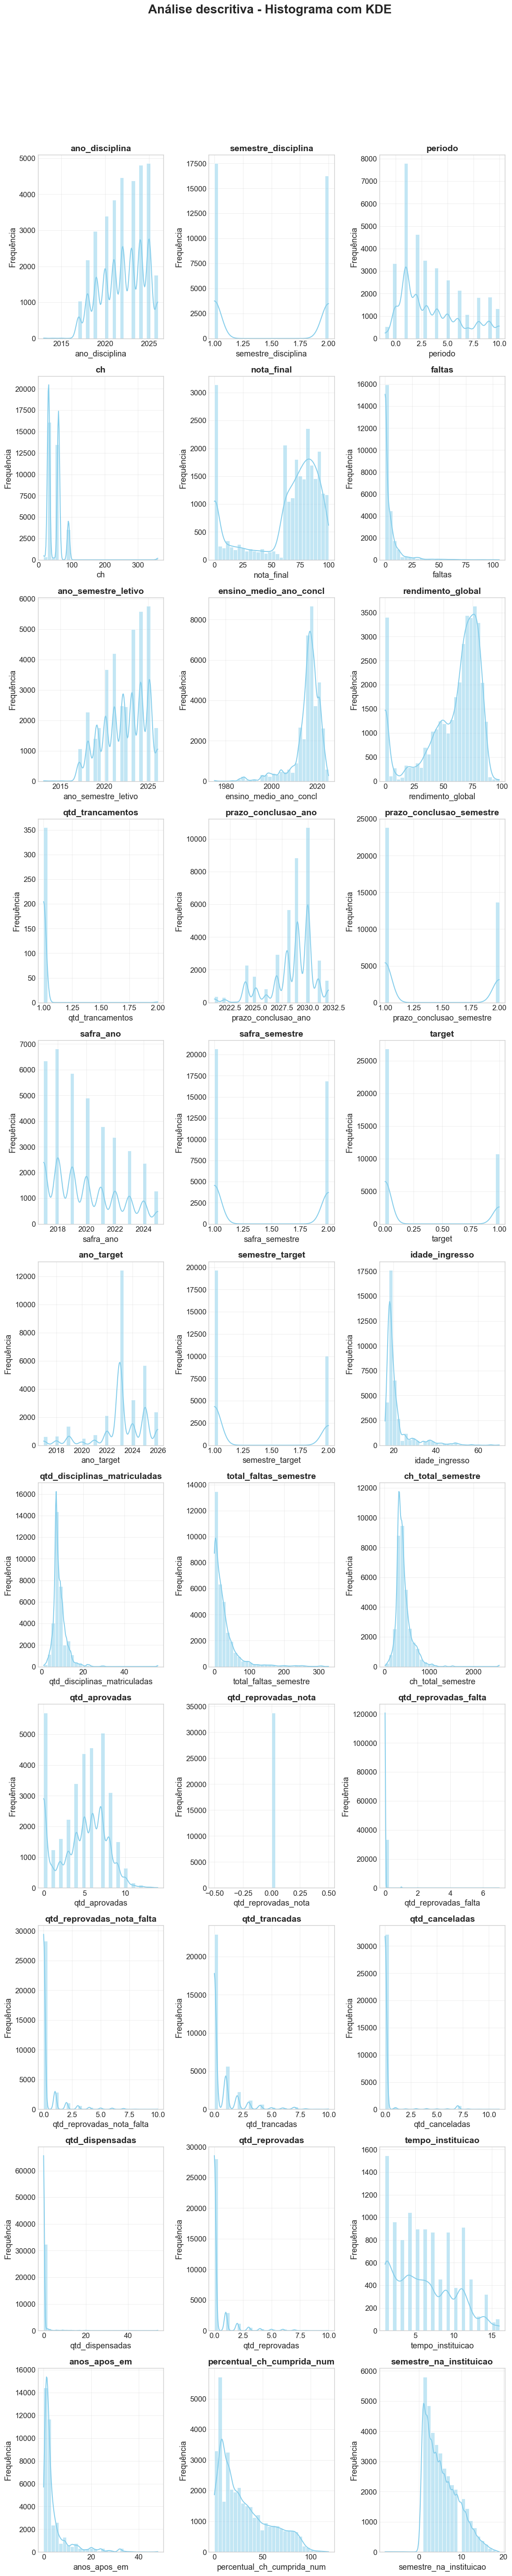

In [1429]:
def histograms_var_num(dataframe):
    """
    Plota histogramas com a curva KDE (Kernel Density Estimation) para todas as variáveis numéricas
    do dataframe fornecido em um painel com 3 gráficos por linha.
    Compatível com tipos float64, int64 e Int64 (nullable integer).

    :param dataframe: DataFrame para o qual os histogramas serão gerados.
    """
    # Seleciona colunas numéricas — inclui Int64 nullable usado no df
    numeric_columns = [
        col for col in dataframe.columns
        if str(dataframe[col].dtype) in ['float64', 'int64', 'Int64']
    ]

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(12, nrows * 5))

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota histogramas com KDE para cada coluna numérica
    for i, column in enumerate(numeric_columns):
        # Converte para float para compatibilidade com KDE (Int64 pode causar erro no seaborn)
        dados = dataframe[column].dropna().astype(float)
        sns.histplot(data=dados, ax=axes[i//3, i%3], color="skyblue", bins=30, kde=True)
        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('Frequência')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - Histograma com KDE", fontsize=20, fontweight='bold', y=1.05)

    plt.show()

# Executar para df
histograms_var_num(df)

In [1430]:
# Definindo função de limites para outlier
# Adaptada para incluir Int64 (nullable integer) além de float64 e int64
def limites_outliers(dataframe, fator_mult_sup=1.5, fator_mult_inf=1.5):
    # fator_mult_sup e fator_mult_inf como parâmetros com valor padrão 1.5
    # permite ajustar os limites por chamada sem alterar a função

    # Tipos numéricos a considerar — inclui Int64 nullable usado no nosso df
    tipos_numericos = ['float64', 'int64', 'Int64']

    for coluna in dataframe.columns:
        if str(dataframe[coluna].dtype) in tipos_numericos:
            print(f'-> VARIÁVEL: `{coluna}`')

            q1 = dataframe[coluna].quantile(.25)
            q3 = dataframe[coluna].quantile(.75)
            IQR = q3 - q1
            print(f'IQR: {IQR}')

            # Definindo limites com fator multiplicativo ajustável
            limite_superior = q3 + 1.5 * IQR
            limite_inferior = q1 - 1.5 * IQR
            print(f'Limite superior: {limite_superior * fator_mult_sup}')
            print(f'Limite inferior: {limite_inferior * fator_mult_inf}')

            # Percentual do dataset que representa outliers
            outliers = dataframe[
                (dataframe[coluna] > (limite_superior * fator_mult_sup)) |
                (dataframe[coluna] < (limite_inferior * fator_mult_inf))
            ]
            print(f'Os outliers da variável "{coluna}" correspondem a '
                  f'{len(outliers)/dataframe.shape[0]:.2%} do dataset\n')

# Executar para todas as variáveis numéricas de df
limites_outliers(df)

-> VARIÁVEL: `ano_disciplina`
IQR: 4
Limite superior: 3045.0
Limite inferior: 3021.0
Os outliers da variável "ano_disciplina" correspondem a 89.86% do dataset

-> VARIÁVEL: `semestre_disciplina`
IQR: 1
Limite superior: 5.25
Limite inferior: -0.75
Os outliers da variável "semestre_disciplina" correspondem a 0.00% do dataset

-> VARIÁVEL: `periodo`
IQR: 4
Limite superior: 16.5
Limite inferior: -7.5
Os outliers da variável "periodo" correspondem a 0.00% do dataset

-> VARIÁVEL: `ch`
IQR: 30
Limite superior: 157.5
Limite inferior: -22.5
Os outliers da variável "ch" correspondem a 0.39% do dataset

-> VARIÁVEL: `nota_final`
IQR: 28.0
Limite superior: 192.0
Limite inferior: 24.0
Os outliers da variável "nota_final" correspondem a 12.33% do dataset

-> VARIÁVEL: `faltas`
IQR: 6.0
Limite superior: 22.5
Limite inferior: -13.5
Os outliers da variável "faltas" correspondem a 3.00% do dataset

-> VARIÁVEL: `ano_semestre_letivo`
IQR: 4.0
Limite superior: 3045.3
Limite inferior: 3021.3
Os outliers d

In [1431]:
df.describe(include='object')

,matricula,curriculo,codigo_disciplina,disciplina,disciplina_curso,tipo,situacao_disciplina,renovacao_matricula,cpf,nome,campus,curso,forma_ingresso,forma_ingresso_categoria,prazo_conclusao,sexo,nome_nacao,naturalidade_estado,naturalidade_municipio,data_nascimento,raca,ensino_medio_escola,tipo_escola,data_ingresso,dataultimamovimentacao:_dia,tipoultimamovimentacao,necessidade_especial,safra,situacao_matricula,percentual_ch_cumprida,data_trancamento_1,data_retorno_1,data_trancamento_2,data_retorno_2,ano_semestre_target,ano_semestre_conclusao,ano_semestre_integralizado,situacao_disciplina_categoria
count,37552,33759,33746,33746,32672,33746,33746,37552,37552,37552,37552,37552,37552,37552,37552,37552,37552,37497,37412,37552,35099,37509,35037,37552,29116,29116,37552,37552,35699,35699,37552,37552,37552,37552,29693,8504,2092,33746
unique,796,5,493,366,21,3,12,2,788,788,1,1,20,6,22,2,6,11,99,739,7,579,2,182,224,12,5,18,5,353,54,15,54,15,19,9,1,5
top,201722080400,9515,2DB.003,CÁLCULO I,ENGENHARIA AMBIENTAL E SANITÁRIA - BELO HORIZONTE,obrigatória,APROVADO,matriculado,"9,486,235,600",FRANCINE ANDRADE SIQUEIRA TEIXEIRA,DIRETORIA DO CAMPUS NOVA SUÍÇA - BELO HORIZONTE,ENGENHARIA AMBIENTAL E SANITÁRIA,SiSU,SISU/ENEM_AMPLA,2030.1,F,Brasil,MG,BELO HORIZONTE,"domingo, maio 11, 1997",Branco,CEFET-MG,publica,"quarta-feira, fevereiro 7, 2018","quarta-feira, fevereiro 1, 2023",CONCLUÍDO,não,2017.1,EM_CURSO,0.00%,não trancou,não trancou,não trancou,não trancou,2023.1,2025.2,2026.1,Aprovado
freq,166,19326,978,985,32133,29594,18907,33759,166,166,37552,37552,13758,25966,8790,21531,37077,36872,26833,238,13369,1556,20927,1164,7488,8504,37246,3577,13356,2643,37195,37197,37195,37197,9085,1893,2092,19606


####**Gráfico das frequências categóricas**

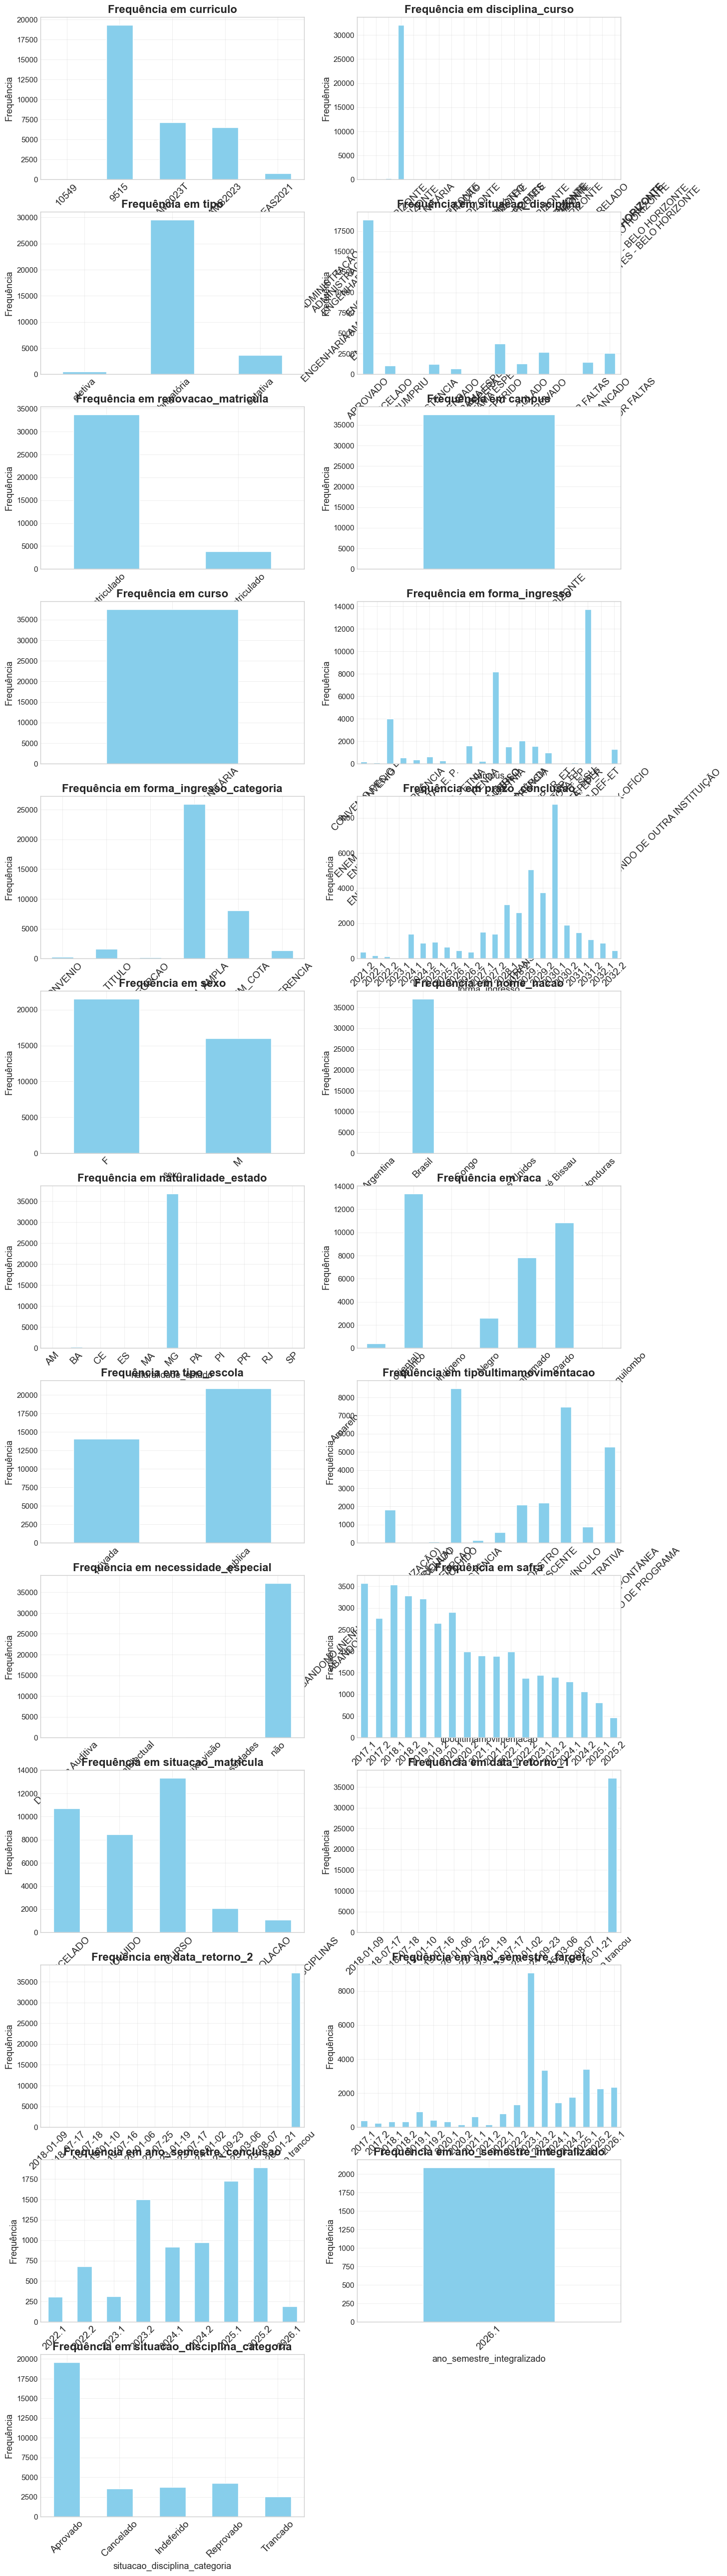

In [1432]:
def plot_categorical_frequency_pt(df, corte_cardinalidade=30, graficos_por_linha=2):
    """
    Plota a frequência de categorias para variáveis categóricas em um DataFrame.

    Parâmetros:
    - df: DataFrame para plotagem.
    - corte_cardinalidade: Cardinalidade máxima para incluir a coluna (padrão 30).
    - graficos_por_linha: Quantidade de gráficos por linha (padrão 2).
    """
    # Gera metadados do DataFrame
    metadados = []
    for coluna in df.columns:
        metadados.append({
            'Variável':      coluna,
            'Tipo':          df[coluna].dtype,
            'Cardinalidade': df[coluna].nunique()
        })
    df_metadados = pd.DataFrame(metadados)

    # Filtra colunas object com cardinalidade dentro do limite
    variaveis_categoricas = df_metadados[
        (df_metadados['Cardinalidade'] <= corte_cardinalidade) &
        (df_metadados['Tipo'] == 'object')
    ]

    # Calcula dimensões do painel
    n_linhas = -(-len(variaveis_categoricas) // graficos_por_linha)  # ceiling division
    n_colunas = min(len(variaveis_categoricas), graficos_por_linha)

    # Inicializa painel
    fig, axs = plt.subplots(nrows=n_linhas, ncols=n_colunas, figsize=(15, 5 * n_linhas))

    # Garante que axs seja sempre 2D — evita erro quando há apenas 1 linha de gráficos
    axs = np.array(axs).reshape(n_linhas, n_colunas)

    # Plota cada variável categórica
    for i, (idx, linha) in enumerate(variaveis_categoricas.iterrows()):
        var = linha['Variável']
        ax = axs[i // graficos_por_linha, i % graficos_por_linha]
        df[var].value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue')
        ax.set_title(f'Frequência em {var}')
        ax.set_ylabel('Frequência')
        ax.set_xlabel(var)
        ax.tick_params(axis='x', rotation=45)  # rotaciona labels para melhor leitura

    # Remove eixos vazios
    for j in range(i + 1, n_linhas * n_colunas):
        axs[j // graficos_por_linha, j % graficos_por_linha].axis('off')

    plt.tight_layout()
    plt.show()

# Executar para df
# corte_cardinalidade=30 já é adequado para a maioria das colunas categóricas do df
plot_categorical_frequency_pt(df, corte_cardinalidade=30, graficos_por_linha=2)

Análise multivariada

In [1433]:
print(df['rendimento_semestral'].dtype)
print(df['rendimento_semestral'].head())

Float64
0    73.692308
1         <NA>
2          0.0
3          0.0
4          0.0
Name: rendimento_semestral, dtype: Float64


In [1434]:
incluidas = [
    col for col in df.columns
    if str(df[col].dtype) in ['float64', 'int64', 'Int64']
    and col != 'target'
]
excluidas = [
    col for col in df.columns
    if str(df[col].dtype) not in ['float64', 'int64', 'Int64']
    and col != 'target'
]

print("Incluídas:", incluidas)
print("\nExcluídas:", excluidas)

Incluídas: ['ano_disciplina', 'semestre_disciplina', 'periodo', 'ch', 'nota_final', 'faltas', 'ano_semestre_letivo', 'ensino_medio_ano_concl', 'rendimento_global', 'qtd_trancamentos', 'prazo_conclusao_ano', 'prazo_conclusao_semestre', 'safra_ano', 'safra_semestre', 'ano_target', 'semestre_target', 'idade_ingresso', 'qtd_disciplinas_matriculadas', 'total_faltas_semestre', 'ch_total_semestre', 'qtd_aprovadas', 'qtd_reprovadas_nota', 'qtd_reprovadas_falta', 'qtd_reprovadas_nota_falta', 'qtd_trancadas', 'qtd_canceladas', 'qtd_dispensadas', 'qtd_reprovadas', 'tempo_instituicao', 'anos_apos_em', 'percentual_ch_cumprida_num', 'semestre_na_instituicao']

Excluídas: ['matricula', 'curriculo', 'codigo_disciplina', 'disciplina', 'disciplina_curso', 'tipo', 'situacao_disciplina', 'renovacao_matricula', 'cpf', 'nome', 'campus', 'curso', 'forma_ingresso', 'forma_ingresso_categoria', 'prazo_conclusao', 'sexo', 'nome_nacao', 'naturalidade_estado', 'naturalidade_municipio', 'data_nascimento', 'raca', '

In [1435]:
def kdeplots_var_num_target(dataframe, target_column):
    """
    Plota kdeplots para todas as variáveis numéricas discriminando pela coluna target.
    Compatível com tipos float64, int64 e Int64 (nullable integer).

    :param dataframe: DataFrame contendo as variáveis numéricas e a coluna target.
    :param target_column: Nome da coluna target binária (0 = não evadiu, 1 = evadiu).
    """
    # Seleciona colunas numéricas — inclui Int64 nullable usado no df
    numeric_columns = [
        col for col in dataframe.columns
        if str(dataframe[col].dtype) in ['float64', 'int64', 'Int64', 'Float64']
        and col != target_column  # evita plotar a própria target como variável
    ]

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(14, nrows * 4))

    # Garante que axes seja sempre 2D
    axes = np.array(axes).reshape(nrows, 3)

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota kdeplots para cada coluna numérica discriminando pelo valor da target
    for i, column in enumerate(numeric_columns):
        # Converte para float para compatibilidade com seaborn (Int64 nullable pode causar erro)
        evadiu     = dataframe[dataframe[target_column] == 1][column].dropna().astype(float)
        nao_evadiu = dataframe[dataframe[target_column] == 0][column].dropna().astype(float)

        sns.kdeplot(data=evadidos,     ax=axes[i//3, i%3], color="red",  label="Evadiu (1)",     fill=True, warn_singular=False)
        sns.kdeplot(data=nao_evadidos, ax=axes[i//3, i%3], color="blue", label="Não evadiu (0)", fill=True, warn_singular=False)

        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('Densidade')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

        if i == 0:
            axes[i//3, i%3].legend(title=target_column)

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - KDE por Target", fontsize=20, fontweight='bold', y=1.00)

    plt.show()

# Executar
kdeplots_var_num_target(df, target_column='target')



NameError: name 'evadidos' is not defined

##### **Gráficos de barras segmentado**

In [ ]:
print(df['periodo'].dtype)

In [ ]:
print(df['periodo'].nunique())
print(df['periodo'].unique())

In [ ]:
# Ver o nome exato de todas as colunas
print(df.columns.tolist())

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
categorical_columns = [col for col in categorical_columns if col != 'target']

filtered = [col for col in categorical_columns if df[col].nunique() <= 15]
print("Colunas incluídas:", filtered)

excluded = [col for col in categorical_columns if df[col].nunique() > 15]
print("Colunas excluídas:", excluded)

In [ ]:
def plot_cat_vs_target_percentage(dataframe, target_column, cutoff=15):
    categorical_columns = dataframe.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if col != target_column]
    categorical_columns_filtered = [
        col for col in categorical_columns
        if dataframe[col].nunique() <= cutoff
    ]

    n_rows = len(categorical_columns_filtered) // 3 + (len(categorical_columns_filtered) % 3 > 0)
    n_cols = min(len(categorical_columns_filtered), 3)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = np.array(axes).reshape(n_rows, n_cols)
    plt.tight_layout(pad=4)

    for i, column in enumerate(categorical_columns_filtered):
        print(f"Plotando coluna: {column}")
        try:
            prop_df = (
                dataframe.groupby([column, target_column]).size()
                / dataframe.groupby(column).size()
            ).unstack()

            ax = axes[i // n_cols, i % n_cols]
            prop_df.plot(kind='bar', stacked=True, ax=ax)
            ax.set_title(column, fontsize=14)
            ax.set_ylabel('Porcentagem')
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            plt.subplots_adjust(wspace=0.5, hspace=0.7)
            print(f"  ✓ OK")
        except Exception as e:
            print(f"  ✗ Erro: {e}")

    for j in range(len(categorical_columns_filtered), n_rows * n_cols):
        fig.delaxes(axes.flatten()[j])

    fig.suptitle(
        "Análise de Variáveis Categóricas em relação ao Target (Porcentagem)",
        fontsize=20, fontweight='bold', y=1.02
    )
    plt.show()

plot_cat_vs_target_percentage(df, target_column='target', cutoff=15)

In [ ]:
## **Utilizando Pandas_Profilling**

In [ ]:
pip install ydata-profiling

In [ ]:
# Importação correta com ydata-profiling
from ydata_profiling import ProfileReport

# Gerar relatório
profile = ProfileReport(df, title='EDA - Evasão CEFET', explorative=True)

# Exibir no Jupyter
profile.to_notebook_iframe()

# Ou salvar como HTML
profile.to_file('eda_evasao_cefet.html')

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
"""
verificar_duplicatas.py
========================
Verifica se as colunas suspeitas de duplicação no df_alunos são realmente redundantes.
Execute em seu Jupyter notebook:
    exec(open('verificar_duplicatas.py').read())
Ou cole diretamente em uma célula.
"""

import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# AJUSTE: informe o nome do seu DataFrame aqui
# ─────────────────────────────────────────────────────────────────────────────
df = df  # <── altere se necessário

# ─────────────────────────────────────────────────────────────────────────────
# Utilitários
# ─────────────────────────────────────────────────────────────────────────────
SEP = "─" * 65

def cabecalho(titulo):
    print(f"\n{SEP}")
    print(f"  {titulo}")
    print(SEP)

def resultado(ok, detalhe=""):
    status = " REDUNDANTE – pode remover" if ok else " DIVERGE – investigar"
    print(f"  {status}")
    if detalhe:
        print(f"  {detalhe}")


# ═════════════════════════════════════════════════════════════════════════════
# 1. percentual_ch_cumprida (object) × percentual_ch_cumprida_num (float)
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("1. percentual_ch_cumprida × percentual_ch_cumprida_num")

pct_str = (
    df["percentual_ch_cumprida"]
    .str.rstrip("%")
    .astype(float)
)
diff_pct = (pct_str - df["percentual_ch_cumprida_num"]).abs().max()
ok = diff_pct < 0.01
resultado(ok, f"Diferença máxima entre as colunas: {diff_pct:.6f}")
print("  → Manter: percentual_ch_cumprida_num  |  Remover: percentual_ch_cumprida")


# ═════════════════════════════════════════════════════════════════════════════
# 2. situacao_disciplina × situacao_disciplina_categoria
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("2. situacao_disciplina → situacao_disciplina_categoria")

mapeamento_esperado = {
    "APROVADO":                        "Aprovado",
    "REPROVADO POR NOTA":              "Reprovado",
    "REPROVADO POR FALTAS":            "Reprovado",
    "REPROVADO POR MÉDIA E POR FALTAS":"Reprovado",
    "TRANCADO":                        "Trancado",
    "CANCELADO":                       "Cancelado",
    "DISPENSADO":                      "Aprovado",   # ajuste se necessário
    "INDEFERIDO":                      "Indeferido",
}

df_check = df[["situacao_disciplina", "situacao_disciplina_categoria"]].dropna()
df_check = df_check.assign(
    categoria_derivada=df_check["situacao_disciplina"].map(mapeamento_esperado)
)

divergencias = df_check[
    df_check["categoria_derivada"] != df_check["situacao_disciplina_categoria"]
]

ok = len(divergencias) == 0
resultado(ok, f"Divergências encontradas: {len(divergencias)}")

if not ok:
    print("\n  Pares com divergência:")
    print(
        divergencias
        .groupby(["situacao_disciplina", "situacao_disciplina_categoria", "categoria_derivada"])
        .size()
        .rename("n")
        .reset_index()
        .to_string(index=False)
    )

# Mostra também os valores únicos para revisar o mapeamento
print("\n  Tabela de frequência (granular → categoria):")
print(
    df_check
    .groupby(["situacao_disciplina", "situacao_disciplina_categoria"])
    .size()
    .rename("n")
    .reset_index()
    .to_string(index=False)
)


# ═════════════════════════════════════════════════════════════════════════════
# 3. forma_ingresso × forma_ingresso_categoria
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("3. forma_ingresso → forma_ingresso_categoria")

print("  Tabela de frequência (forma → categoria):")
print(
    df.groupby(["forma_ingresso", "forma_ingresso_categoria"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values("forma_ingresso")
    .to_string(index=False)
)
print("  → Verifique se cada forma_ingresso mapeia para UMA única categoria.")
n_categorias_por_forma = (
    df.groupby("forma_ingresso")["forma_ingresso_categoria"].nunique()
)
ok = (n_categorias_por_forma == 1).all()
resultado(ok, "Cada forma_ingresso possui exatamente uma categoria?" + (" Sim." if ok else " Não."))


# ═════════════════════════════════════════════════════════════════════════════
# 4. safra_ano + safra_semestre → safra
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("4. safra_ano + safra_semestre → safra")

safra_derivada = (
    df["safra_ano"].astype(str) + "." + df["safra_semestre"].astype(str)
)
divergencias = (safra_derivada != df["safra"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes: {divergencias}")
if not ok:
    print(df[safra_derivada != df["safra"]][["safra_ano", "safra_semestre", "safra"]].head())


# ═════════════════════════════════════════════════════════════════════════════
# 5. prazo_conclusao_ano + prazo_conclusao_semestre → prazo_conclusao
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("5. prazo_conclusao_ano + prazo_conclusao_semestre → prazo_conclusao")

prazo_derivado = (
    df["prazo_conclusao_ano"].astype(str) + "." + df["prazo_conclusao_semestre"].astype(str)
)
divergencias = (prazo_derivado != df["prazo_conclusao"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes: {divergencias}")
if not ok:
    print(df[prazo_derivado != df["prazo_conclusao"]][
        ["prazo_conclusao_ano", "prazo_conclusao_semestre", "prazo_conclusao"]
    ].head())


# ═════════════════════════════════════════════════════════════════════════════
# 6. ano_disciplina + semestre_disciplina → ano_semestre_letivo
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("6. ano_disciplina + semestre_disciplina → ano_semestre_letivo")

letivo_derivado = (
    df["ano_disciplina"].astype(float) + df["semestre_disciplina"].astype(float) / 10
)
diff = (letivo_derivado - df["ano_semestre_letivo"]).abs().max()
ok = diff < 0.001
resultado(ok, f"Diferença máxima: {diff:.6f}")
if not ok:
    mask = (letivo_derivado - df["ano_semestre_letivo"]).abs() > 0.001
    print(df[mask][["ano_disciplina", "semestre_disciplina", "ano_semestre_letivo"]].head())


# ═════════════════════════════════════════════════════════════════════════════
# 7. ano_target + semestre_target → ano_semestre_target
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("7. ano_target + semestre_target → ano_semestre_target")

mask_notna = df["ano_target"].notna() & df["semestre_target"].notna()
target_derivado = (
    df.loc[mask_notna, "ano_target"].astype(int).astype(str)
    + "."
    + df.loc[mask_notna, "semestre_target"].astype(int).astype(str)
)
divergencias = (target_derivado != df.loc[mask_notna, "ano_semestre_target"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes (excluindo nulos): {divergencias}")
if not ok:
    mask_div = target_derivado != df.loc[mask_notna, "ano_semestre_target"]
    print(df.loc[mask_notna][mask_div][
        ["ano_target", "semestre_target", "ano_semestre_target"]
    ].head())


# ═════════════════════════════════════════════════════════════════════════════
# 8. semestre_na_instituicao × tempo_instituicao
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("8. semestre_na_instituicao × tempo_instituicao")

mask_ambos = df["semestre_na_instituicao"].notna() & df["tempo_instituicao"].notna()
sub = df.loc[mask_ambos, ["semestre_na_instituicao", "tempo_instituicao"]]

print(f"  Registros com ambas preenchidas: {mask_ambos.sum()} de {len(df)}")
print(f"  semestre_na_instituicao — únicos: {sub['semestre_na_instituicao'].nunique()}, "
      f"range: {sub['semestre_na_instituicao'].min()} – {sub['semestre_na_instituicao'].max()}")
print(f"  tempo_instituicao       — únicos: {sub['tempo_instituicao'].nunique()}, "
      f"range: {sub['tempo_instituicao'].min()} – {sub['tempo_instituicao'].max()}")

# Testa hipótese: tempo_instituicao = semestre_na_instituicao / 2
razao = (sub["semestre_na_instituicao"] / sub["tempo_instituicao"]).describe()
print(f"\n  Razão semestre/tempo:\n{razao.to_string()}")
corr = sub["semestre_na_instituicao"].corr(sub["tempo_instituicao"])
print(f"\n  Correlação de Pearson: {corr:.4f}")
if corr > 0.95:
    print("    Alta correlação — provavelmente medem o mesmo conceito em escalas diferentes.")
else:
    print("  Correlação baixa — parecem medir conceitos distintos. Manter ambas.")


# ═════════════════════════════════════════════════════════════════════════════
# 9. data_trancamento_1 × data_trancamento_2 | data_retorno_1 × data_retorno_2
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("9. Pares de trancamento (_1 × _2)")

for par in [("data_trancamento_1", "data_trancamento_2"),
            ("data_retorno_1", "data_retorno_2")]:
    c1, c2 = par
    iguais = (df[c1] == df[c2]).sum()
    diff2_real = (df[c2] != "não trancou").sum()
    print(f"\n  {c1} × {c2}")
    print(f"    Registros idênticos entre as duas:       {iguais} / {len(df)}")
    print(f"    Registros em _2 com data real (≠ 'não trancou'): {diff2_real}")
    if diff2_real == 0:
        print("     _2 é sempre 'não trancou' — remover com segurança.")
    else:
        print(f"     {diff2_real} alunos tiveram 2º trancamento. Avaliar se é relevante.")


# ═════════════════════════════════════════════════════════════════════════════
# 10. Colunas constantes (variância zero)
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("10. Colunas constantes (1 valor único)")

constantes = [
    "renovacao_matricula",
    "campus",
    "curso",
    "qtd_trancamentos",
    "ano_semestre_integralizado",
]

for col in constantes:
    n_uniq = df[col].nunique(dropna=False)
    pct_nulo = df[col].isna().mean() * 100
    valores = df[col].dropna().unique()
    print(f"\n  {col}")
    print(f"    Valores únicos (c/ nulo): {n_uniq}  |  % nulo: {pct_nulo:.1f}%")
    print(f"    Valores: {list(valores)[:5]}")
    if n_uniq <= 2:
        print("  Constante — zero variância preditiva. Remover.")
    else:
        print("   Mais de 1 valor único — revisar antes de remover.")


# ═════════════════════════════════════════════════════════════════════════════
# RESUMO FINAL
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*65}")
print("  RESUMO – Colunas candidatas à remoção após confirmação")
print(f"{'═'*65}")
candidatas = {
    "Formato duplicado":        ["percentual_ch_cumprida"],
    "Versão agrupada":          ["situacao_disciplina_categoria", "forma_ingresso_categoria"],
    "Coluna composta (= partes)":["safra", "prazo_conclusao", "ano_semestre_letivo", "ano_semestre_target"],
    "Soma de componentes":      ["qtd_reprovadas"],
    "Near-constantes":          ["renovacao_matricula", "campus", "curso",
                                 "qtd_trancamentos", "ano_semestre_integralizado"],
}
for grupo, cols in candidatas.items():
    print(f"\n  [{grupo}]")
    for c in cols:
        print(f"    • {c}")

print(f"\n{SEP}")
print("  Script concluído.")
print(SEP)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Remoção de colunas redundantes — df_alunos
# ─────────────────────────────────────────────────────────────────

colunas_remover = {

    # Formato duplicado: string com % → manter a numérica
    "formato_duplicado": [
        "percentual_ch_cumprida",
    ],

    # Versões agrupadas: deriváveis das granulares
    "versao_agrupada": [
        "situacao_disciplina_categoria",
        "forma_ingresso_categoria",
    ],

    # Componentes numéricos: deriváveis das colunas compostas mantidas
    # safra_ano + safra_semestre  →  safra
    # prazo_conclusao_ano/semestre  →  prazo_conclusao
    # ano_disciplina + semestre_disciplina  →  ano_semestre_letivo
    # ano_target + semestre_target  →  ano_semestre_target
    "componentes_numericos": [
        "safra_ano",
        "safra_semestre",
        "prazo_conclusao_ano",
        "prazo_conclusao_semestre",
        "ano_disciplina",
        "semestre_disciplina",
        "ano_target",
        "semestre_target",
    ],

    # Soma de componentes: qtd_reprovadas = nota + falta + nota_falta
    "soma_componentes": [
        "qtd_reprovadas",
    ],

    # Duplicatas literais: _1 e _2 são idênticas em todos os registros
    # Os 2 alunos com 2º trancamento têm o mesmo valor em _1 e _2
    # → manter _1, remover _2
    "duplicatas_literais": [
        "data_trancamento_2",
        "data_retorno_2",
        
    # Constantes: variância zero, sem poder preditivo
    "constantes": [
        "renovacao_matricula",
        "qtd_trancamentos",
        "ano_semestre_integralizado",
    ],
}

# Achata o dicionário em lista única
todas_remover = [col for cols in colunas_remover.values() for col in cols]

# Verifica se todas existem antes de remover
ausentes = [c for c in todas_remover if c not in df_alunos.columns]
if ausentes:
    print(f"Colunas não encontradas no DataFrame: {ausentes}")
else:
    shape_antes = df_alunos.shape
    df_alunos = df_alunos.drop(columns=todas_remover)
    shape_depois = df_alunos.shape

    print(f" Remoção concluída")
    print(f"   Colunas removidas : {shape_antes[1] - shape_depois[1]}")
    print(f"   Shape antes       : {shape_antes}")
    print(f"   Shape depois      : {shape_depois}")
    print(f"\nColunas restantes ({shape_depois[1]}):")
    print(df_alunos.columns.tolist())

In [ ]:
def gerar_dicionario_dados(dataframe):
    """
    Gera um dicionário de dados com metadados das colunas do dataframe fornecido.
    """
    registros = []

    for col in dataframe.columns:
        registros.append({
            'Coluna':             col,
            'Tipo_Dado':          str(dataframe[col].dtype),
            'Valores_Unicos':     dataframe[col].nunique(),
            'Total_Registros':    len(dataframe),
            'Nulos':              dataframe[col].isnull().sum(),
            'Percentual_Nulos':   round(dataframe[col].isnull().mean() * 100, 2),
            'Amostra_Valores':    dataframe[col].dropna().unique()[:5].tolist(),
            'Descricao':          ''   # preencher manualmente depois
        })

    dicionario = pd.DataFrame(registros)
    dicionario = dicionario.sort_values(by='Tipo_Dado').reset_index(drop=True)

    return dicionario


dicionario_df_alunos = gerar_dicionario_dados(df_alunos)
dicionario_df_alunos

In [ ]:
caminho_saida = r'C:\Users\clari\Desktop\Ciência de dados\Portfolio\Evasão\Cefet\Modelo\nova_suica\eng_amb\data_lake\003_trusted\dicionario_df_alunos.xlsx'

dicionario_df_alunos.to_excel(caminho_saida, index=False)

print(f'Arquivo salvo em: {caminho_saida}')